## P2: Data exploratory analysis (EDA)

In [136]:
# import libraries

import pandas as pd
import numpy as np

# vidualization 
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# format
pd.set_option('display.max_rows', None) 
pd.set_option('display.max_columns', None) 
import requests
import warnings
from collections import Counter
warnings.simplefilter(action='ignore', category=FutureWarning)

In [137]:
# Load the data into DF
df = pd.read_csv('completed_file.csv')

In [138]:
# Data summary
df.head()

,Date,Title,Company,State,City,Level,Work Mode,Average Salary,Pay Type,Employment Type,Description
0,2024-06-23,Data Scientist,"Dese Research, Inc.",Alabama,Huntsville,Mid-level,On-Site,NaN,NaN,NaN,"Familiarity with advanced machine learning, da..."
1,2024-06-23,Senior Data Analyst,Pci Government Services,Alabama,Huntsville,Senior,On-Site,85000.0,year,NaN,Must have strong technical skills in areas suc...
2,2024-06-23,Data Scientist,"Interclypse, Inc.",Alabama,Huntsville,Mid-level,On-Site,NaN,NaN,Full-time,Excellent interpersonal skills and ability to ...
3,2024-06-23,"Data Scientist, Mid",Booz Allen,Alabama,Huntsville,Mid-level,On-Site,123800.0,year,NaN,"As a data scientist, you’re excited at the pro..."
4,2024-06-23,Senior Data Analyst (u.s. Remote Eligible),"Eternal Word Television Network, Inc.",Alabama,Alabama,Senior,Remote,NaN,NaN,NaN,You are experienced using web analytics and Go...


In [139]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29184 entries, 0 to 29183
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Date             29184 non-null  object 
 1   Title            29184 non-null  object 
 2   Company          29184 non-null  object 
 3   State            29184 non-null  object 
 4   City             29182 non-null  object 
 5   Level            29184 non-null  object 
 6   Work Mode        29184 non-null  object 
 7   Average Salary   11377 non-null  float64
 8   Pay Type         11437 non-null  object 
 9   Employment Type  4905 non-null   object 
 10  Description      22755 non-null  object 
dtypes: float64(1), object(10)
memory usage: 2.4+ MB


In [140]:
print(df.duplicated().sum()) # check duplicated rows
print(df.isna().sum()) # check missing rows

16
Date                   0
Title                  0
Company                0
State                  0
City                   2
Level                  0
Work Mode              0
Average Salary     17807
Pay Type           17747
Employment Type    24279
Description         6429
dtype: int64


For the purpose of this EDA, the missing salary will not be removed because some company do not disclosed their salary. And these missing salary records still valuable for the exploration.

In [141]:
# remove duplicated data

df = df.drop_duplicates()

In [142]:
# data size after remove duplicated records
df.shape

(29168, 11)

In [143]:
# convert Data column into Data Time data type

df['Date'] = pd.to_datetime(df['Date'])

In [144]:
# Generate summary statistics using the describe() method.
df.describe(include = 'all')

,Date,Title,Company,State,City,Level,Work Mode,Average Salary,Pay Type,Employment Type,Description
count,29168,29168,29168,29168,29166,29168,29168,1.137100e+04,11431,4901,22744
unique,NaN,8124,4078,52,1043,8,3,NaN,5,27,12956
top,NaN,Data Scientist,Amazon.com Services Llc,California,Remote,Mid-level,On-Site,NaN,year,Full-time,"Note: Apple benefit, compensation and employee..."
freq,NaN,1427,948,5397,1959,17545,28048,NaN,10735,4556,139
mean,2024-07-15 05:31:57.498628608,NaN,NaN,NaN,NaN,NaN,NaN,1.536247e+05,NaN,NaN,NaN
min,2024-06-23 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,9.000000e+00,NaN,NaN,NaN
25%,2024-06-27 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,1.238000e+05,NaN,NaN,NaN
50%,2024-07-17 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,1.563025e+05,NaN,NaN,NaN
75%,2024-07-31 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,1.908000e+05,NaN,NaN,NaN
max,2024-08-11 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,1.350000e+06,NaN,NaN,NaN


Handling missing values and correct inconsistent data

`Contract`

In [145]:
# clean Contract column` 
def simplify_work_type(x):
    if pd.isna(x):  # check for NaN
        return np.nan
    x = str(x)
    if 'Full-time' in x:
        return 'Full-time'
    elif 'Permanent' in x:
        return 'Full-time'
    elif 'Part-time' in x:
        return 'Part-time'
    elif 'Internship' in x:
        return 'Internship'
    else:
        return 'Casual'

df['Employment Type'] = df['Employment Type'].apply(simplify_work_type)

df['Employment Type'].value_counts()

Employment Type
Full-time     4618
Casual         228
Part-time       44
Internship      11
Name: count, dtype: int64

Use **rule-based imputation**, assuming that pay types of hour, day, or week correspond to Casual, month corresponds to Part-time, and year corresponds to Full-time.

In [146]:
df.loc[df['Pay Type'] == 'year', 'Employment Type'] = df.loc[df['Pay Type'] == 'year', 'Employment Type'].fillna('Full-time')
df.loc[df['Pay Type'] == 'month', 'Employment Type'] = df.loc[df['Pay Type'] == 'month', 'Employment Type'].fillna('Part-time')
df.loc[df['Pay Type'].isin(['hour', 'day', 'week']), 'Employment Type'] = df.loc[df['Pay Type'].isin(['hour', 'day', 'week']), 'Employment Type'].fillna('Casual')

In [147]:
df['Employment Type'].value_counts()

Employment Type
Full-time     15353
Casual          807
Part-time       101
Internship       11
Name: count, dtype: int64

In [148]:
# fill remaing missing contract values with the most frequent values

mode = df['Employment Type'].mode()[0]
df['Employment Type'] = df['Employment Type'].fillna(mode)

In [149]:
# fill missing description with 'NA' values

df['Description'] = df['Description'].fillna('NA')


In [150]:

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 29168 entries, 0 to 29183
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Date             29168 non-null  datetime64[ns]
 1   Title            29168 non-null  object        
 2   Company          29168 non-null  object        
 3   State            29168 non-null  object        
 4   City             29166 non-null  object        
 5   Level            29168 non-null  object        
 6   Work Mode        29168 non-null  object        
 7   Average Salary   11371 non-null  float64       
 8   Pay Type         11431 non-null  object        
 9   Employment Type  29168 non-null  object        
 10  Description      29168 non-null  object        
dtypes: datetime64[ns](1), float64(1), object(9)
memory usage: 2.7+ MB


## Explore by visualizations

`Average Salary`

Begin by examining the spread and distribution of important variables using box plots and histograms.

In [151]:
df_sal = df.dropna(subset=['Average Salary'])

In [152]:

def to_annual_salary(row):
    salary = row['Average Salary']
    pay_type = row['Pay Type']
    
    if pd.isna(salary) or pd.isna(pay_type):
        return np.nan
    
    pay_type = pay_type.lower()  # make case-insensitive
    
    if pay_type == 'month':
        return salary * 12
    elif pay_type == 'week':
        return salary * 52
    elif pay_type == 'day':
        return salary * 365
    elif pay_type == 'hour':
        return salary * 40 * 52  # assuming 40 hours/week
    else:
        return salary  


In [153]:
# drop missing column in salary for salary insights
df_sal['Annual Salary'] = df_sal.apply(to_annual_salary, axis=1)

/var/folders/5v/wc8gxzt56gx00tb3h88t55vm0000gn/T/ipykernel_25265/1968587141.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sal['Annual Salary'] = df_sal.apply(to_annual_salary, axis=1)


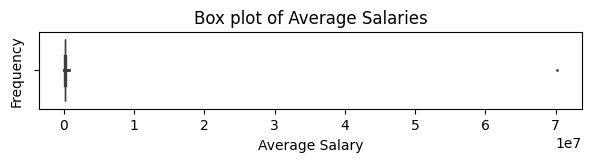

In [154]:
# create a box plot to detect outliers
salary = df_sal['Annual Salary']

plt.figure(figsize=(7,1))
sns.boxplot(x = salary,  fliersize=1)
plt.title('Box plot of Average Salaries')
plt.xlabel('Average Salary')
plt.ylabel('Frequency')
plt.show()

In [155]:
# check the outlier over 700k annual salary
df_sal[df_sal['Annual Salary'] >= 700000]

,Date,Title,Company,State,City,Level,Work Mode,Average Salary,Pay Type,Employment Type,Description,Annual Salary
13386,2024-07-15,Graduate Research Assistant/ Mathematical & St...,The University Of Texas Rio Grande Valley,Texas,Rio Grande Valley,Graduate,On-Site,1350000.0,week,Casual,The Graduate Research Assistants will assist a...,70200000.0


The data appear as errorness from cleaning step, so devide the average salary into 1000 to corretc.

In [156]:
# Update only the Average Salary column for this row
mask = df_sal['Annual Salary'] >= 700000
df_sal.loc[mask, 'Average Salary'] = df_sal.loc[mask, 'Average Salary'] / 1000

In [157]:
# reapply the annual salary convert function

df_sal['Annual Salary'] = df_sal.apply(to_annual_salary, axis=1)

/var/folders/5v/wc8gxzt56gx00tb3h88t55vm0000gn/T/ipykernel_25265/4061111081.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sal['Annual Salary'] = df_sal.apply(to_annual_salary, axis=1)


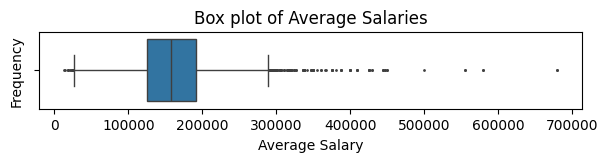

In [158]:
# create a new box plot for annual salary
salary = df_sal['Annual Salary']

plt.figure(figsize=(7,1))
sns.boxplot(x = salary,  fliersize=1)
plt.title('Box plot of Average Salaries')
plt.xlabel('Average Salary')
plt.ylabel('Frequency')
plt.show()

In [159]:
# detect and inspect outliers row

q1 = df_sal['Annual Salary'].quantile(0.25)
q3 = df_sal['Annual Salary'].quantile(0.75)
iqr = q3 - q1
lower_limit = q1 - 1.5 * iqr
upper_limit = q3 + 1.5 * iqr

print(lower_limit, upper_limit)


26000.0 290000.0


In [160]:
outliers = df_sal[(df_sal['Annual Salary'] <= lower_limit) | (df_sal['Annual Salary'] >= upper_limit)]

print('Number of outliers', outliers.shape[0])
print('Percentage of outliers', outliers.shape[0] / df.shape[0] * 100)

outliers.head()

Number of outliers 163
Percentage of outliers 0.5588315962698848


,Date,Title,Company,State,City,Level,Work Mode,Average Salary,Pay Type,Employment Type,Description,Annual Salary
214,2024-06-23,"Data Scientist Lead, Tiktok Live - Trust & Safety",Tiktok,California,San Jose,Lead,On-Site,298140.0,year,Full-time,Collaborate closely with cross-functional team...,298140.0
256,2024-06-23,"Director Data Science, Instagram Business",Instagram,California,Menlo Park,Mid-level,On-Site,337500.0,year,Full-time,"Inspire, lead and grow a team of data scientis...",337500.0
306,2024-06-23,Director Data Science,Meta,California,Burlingame,Mid-level,On-Site,337500.0,year,Full-time,Experience with both product analytics and bus...,337500.0
345,2024-06-23,Head Of Ai And Data Science,Verily,California,San Francisco,Mid-level,On-Site,298000.0,year,Full-time,Strong track record of shipping products that ...,298000.0
412,2024-06-23,"Data Science Director, Monetization Ranking Ai",Facebook App,California,Menlo Park,Mid-level,On-Site,337500.0,year,Full-time,"Inspire, lead and grow a team of data scientis...",337500.0


For this analysis, we will keep the outliers because:
- Very small proportion: 0.55% is tiny, so it won’t heavily skew overall statistics like mean or median.
- Potentially valuable information: Even a few outliers can reveal meaningful insights, such as underpaid or overpaid roles or unusual company practices.
- Analysis type matters: For descriptive analysis or exploratory data analysis (EDA), keeping them is useful. For certain models (like linear regression), we might consider checking sensitivity, but tree-based models are robust to outliers.

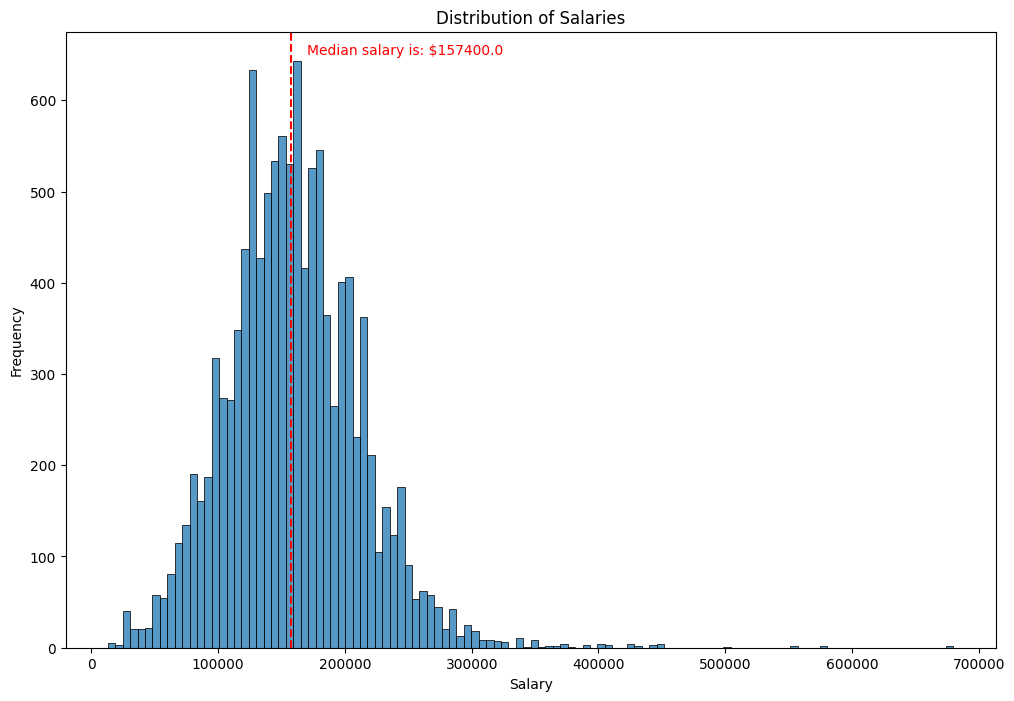

In [161]:
# create a histogram to for annual salary distribution
median = df_sal['Annual Salary'].median()
median_text = 'Median salary is: ' +'$'+ str(median) 

plt.figure(figsize=(12, 8))
sns.histplot(salary)
plt.axvline(median, color = 'red', linestyle='--')
plt.text(170000,650, median_text, color='red')
plt.title('Distribution of Salaries')
plt.xlabel('Salary')
plt.ylabel('Frequency')
plt.show()

`Date`

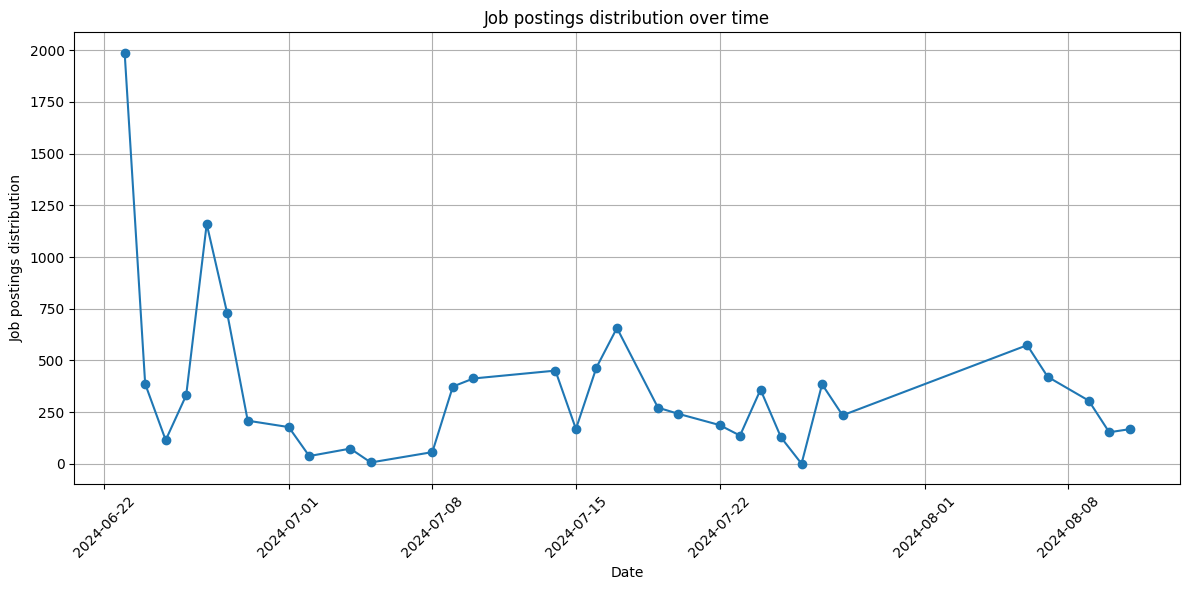

In [162]:
job_postings_count = df_sal.groupby('Date').size()

# Plotting
plt.figure(figsize=(12, 6))
plt.plot(job_postings_count.index, job_postings_count.values, marker='o', linestyle='-')
plt.xlabel('Date')
plt.ylabel('Job postings distribution')
plt.title('Job postings distribution over time')
plt.xticks(rotation=45) 
plt.tight_layout()
plt.grid(True) 

Create a `Weekday` column to visualzie the week day posting trend

In [163]:
# Generate new columns weekday 

df_sal['Weekday'] = df_sal['Date'].dt.day_name()

/var/folders/5v/wc8gxzt56gx00tb3h88t55vm0000gn/T/ipykernel_25265/2811826876.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sal['Weekday'] = df_sal['Date'].dt.day_name()


In [164]:
# Define weekday order

weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Count total job posts per weekday
posts_per_weekday = df_sal.groupby('Weekday').size()

# Count number of unique dates each weekday appears
weekday_dates = df_sal.groupby('Weekday')['Date'].nunique()

# Average posts per weekday occurrence
avg_posts_per_weekday = round(posts_per_weekday / weekday_dates)

# Convert index to Categorical to enforce weekday order
avg_posts_per_weekday = avg_posts_per_weekday.reindex(weekday_order)

print(avg_posts_per_weekday)


Weekday
Monday       196.0
Tuesday      284.0
Wednesday    436.0
Thursday     454.0
Friday       263.0
Saturday     247.0
Sunday       710.0
dtype: float64


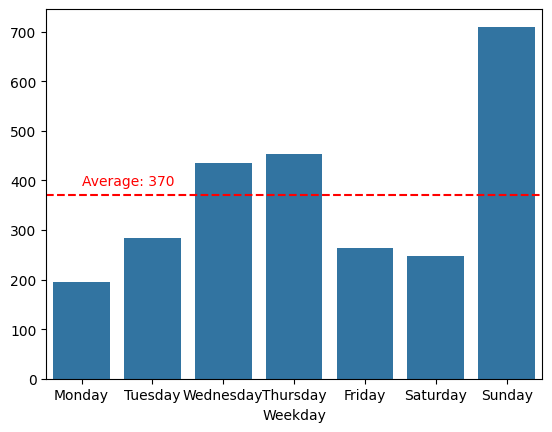

In [165]:
# plot the average job postings by weekday
sns.barplot(x=avg_posts_per_weekday.index, y=avg_posts_per_weekday.values)
overall_avg = avg_posts_per_weekday.mean()
plt.axhline(overall_avg, color='red', linestyle='--')
plt.text(0, 390, f"Average: {overall_avg:.0f}", color='red')
plt.show()

Sunday shows the highest number of job postings during this period, which suggests that the data collection process is inconsistent and may involve more scraping on weekends. Therefore, this pattern does not accurately reflect the true trend of weekday job postings.

`State`, `City`, `Company`, `Title`

In [166]:
print('Number of State: ', df_sal['State'].nunique())
print('Number of City: ', df_sal['City'].nunique())
print('Number of Company: ', df_sal['Company'].nunique())
print('Number of Title: ', df_sal['Title'].nunique())

Number of State:  52
Number of City:  738
Number of Company:  2248
Number of Title:  4763


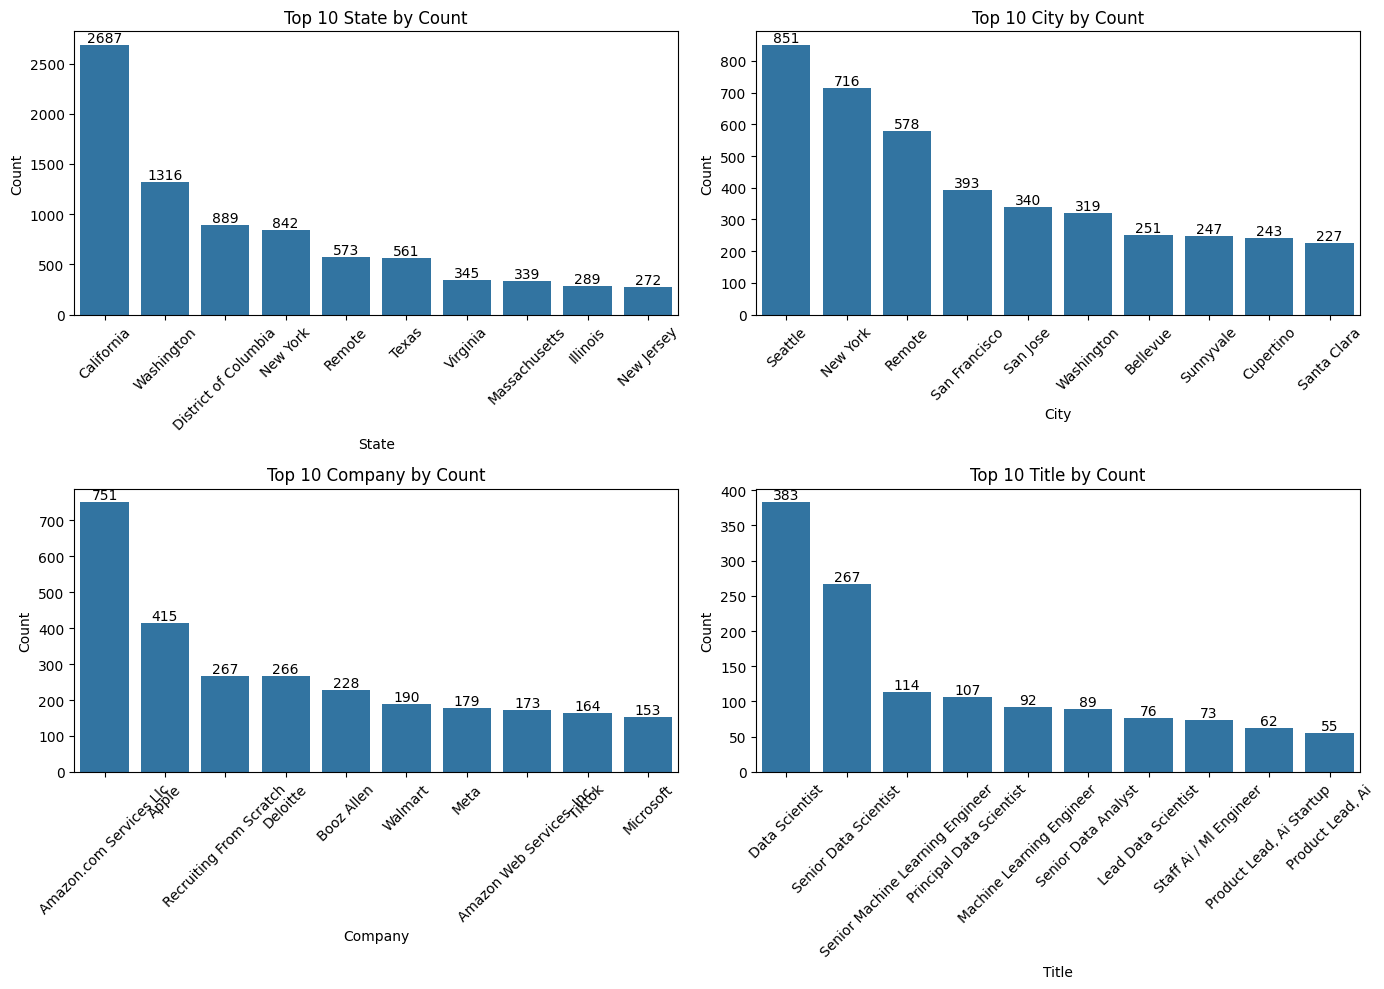

In [167]:
# Plot top 10 states, city, company, title by number of postings

cols = ['State', 'City', 'Company', 'Title']
fig, ax = plt.subplots(2, 2, figsize=(14, 10))

for i, col in enumerate(cols):
    top10 = df_sal[col].value_counts().head(10)
    row = i // 2
    col_idx = i % 2

    sns.countplot(x=col, data=df_sal, order=top10.index, ax=ax[row, col_idx])
    
    ax[row, col_idx].set_title(f'Top 10 {col} by Count')
    ax[row, col_idx].set_ylabel('Count')
    ax[row, col_idx].tick_params(axis='x', rotation=45)
    ax[row, col_idx].bar_label(ax[row, col_idx].containers[0])

plt.tight_layout()
plt.show()


- Unsurprisingly, California leads in data science hiring, driven by its concentration of major tech companies, particularly in the San Francisco Bay Area, Silicon Valley, and Los Angeles.
- Remote positions also appear prominently in the state and city charts, likely because some companies either operate fully remotely or do not disclose a physical office location.
- Amazon.com Services LLC is the company with the most job postings in the dataset.
- Data scientist roles, including variants like Senior Data Scientist or Lead Data Scientist, are the most frequently listed job titles.

`Level`, `Work Mode`, `Pay Type`

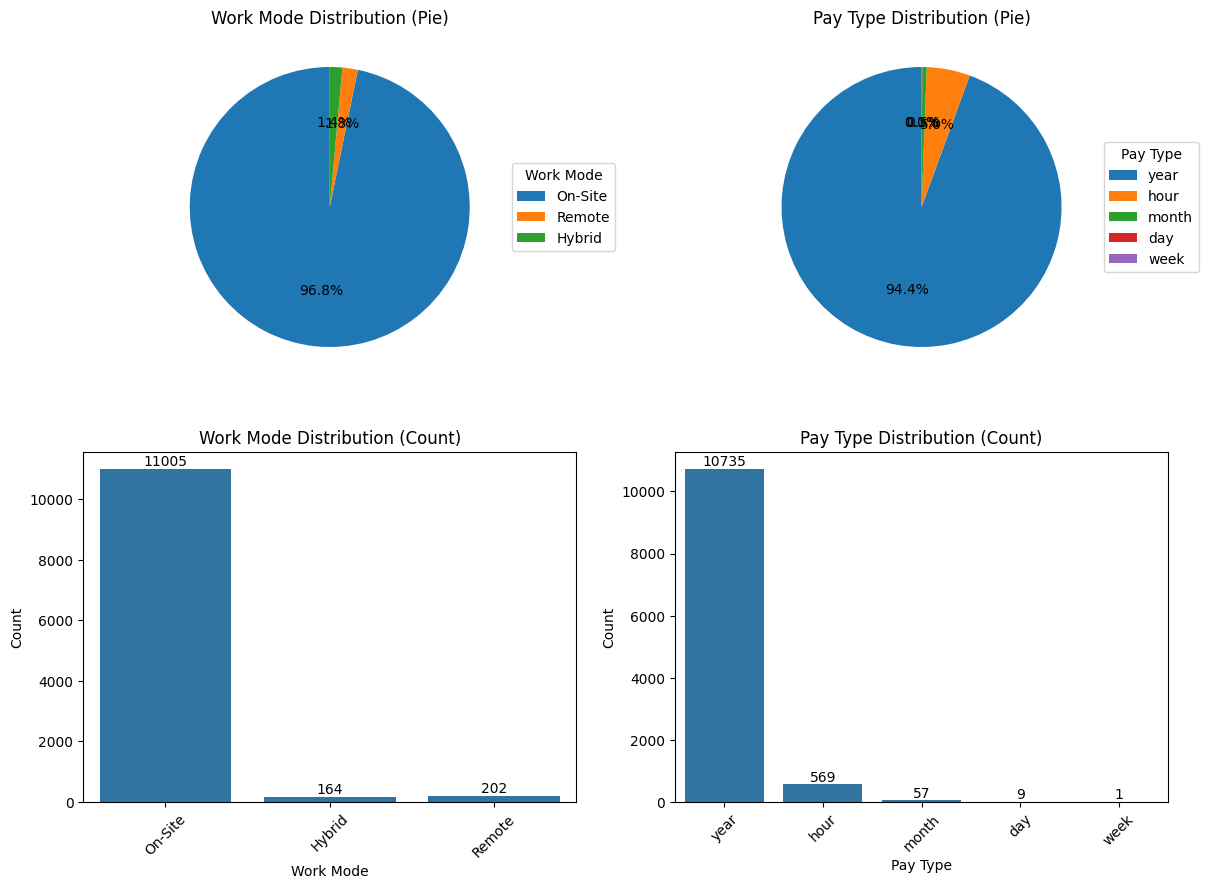

In [168]:
cols = ['Work Mode', 'Pay Type']

fig, ax = plt.subplots(2, 2, figsize=(14, 10))

for i, col in enumerate(cols):
    # ---- Pie chart ----
    counts = df_sal[col].value_counts()
    wedges, texts, autotexts = ax[0, i].pie(counts, labels=None,autopct='%1.1f%%', startangle=90)
    ax[0, i].set_title(f'{col} Distribution (Pie)')
    ax[0, i].legend(wedges, counts.index, title=col, loc='center left', bbox_to_anchor=(1, 0, 0.5, 1))

    # ---- Countplot ----
    sns.countplot(x=col, data=df_sal, ax=ax[1, i])
    ax[1, i].set_title(f'{col} Distribution (Count)')
    ax[1, i].set_ylabel('Count')
    ax[1, i].tick_params(axis='x', rotation=45)
    ax[1, i].bar_label(ax[1, i].containers[0])
plt.show()

- Mid-level roles are the most in-demand (59.7%), with senior roles (24.3%), showing employers are prioritizing experienced talent.
- Onsite work overwhelmingly dominates at 96.8%, indicating limited flexibility in work arrangements.
- Nearly all postings (94.4%) are full-time, as “Year”-based pay structures strongly align with permanent employment.


`Contract`

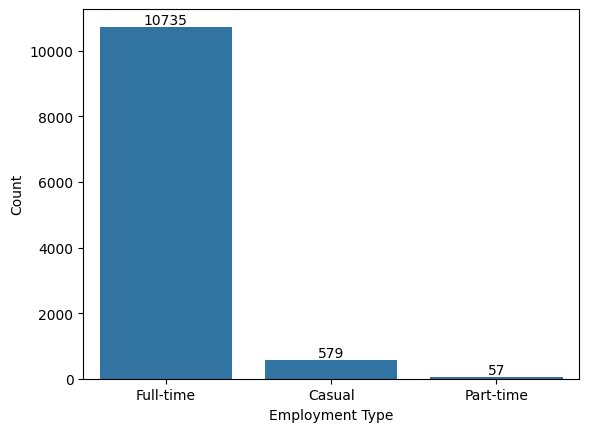

/var/folders/5v/wc8gxzt56gx00tb3h88t55vm0000gn/T/ipykernel_25265/3081454093.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sal['salary_pw'] = df_sal[['Annual Salary']] / 52


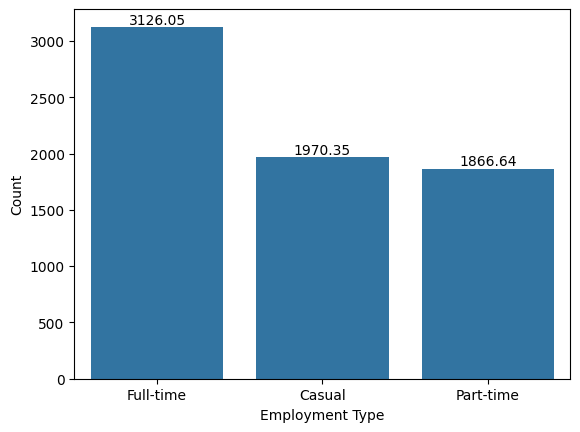

In [169]:
to_plot1 = df_sal['Employment Type'].value_counts().sort_values(ascending=False)

ax = sns.barplot(x=to_plot1.index, y = to_plot.values)
ax.bar_label(ax.containers[0])
plt.ylabel('Count')
plt.show()

#avg salary per week by contract

df_sal['salary_pw'] = df_sal[['Annual Salary']] / 52
to_plot2 = df_sal.groupby('Employment Type')['salary_pw'].mean().sort_values(ascending=False)
ax = sns.barplot(x=to_plot2.index, y = to_plot2.values)
ax.bar_label(ax.containers[0])
plt.ylabel('Count')
plt.show()

`Salary` by `Job level`

/var/folders/5v/wc8gxzt56gx00tb3h88t55vm0000gn/T/ipykernel_25265/816438550.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=45)
/var/folders/5v/wc8gxzt56gx00tb3h88t55vm0000gn/T/ipykernel_25265/816438550.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation=45)


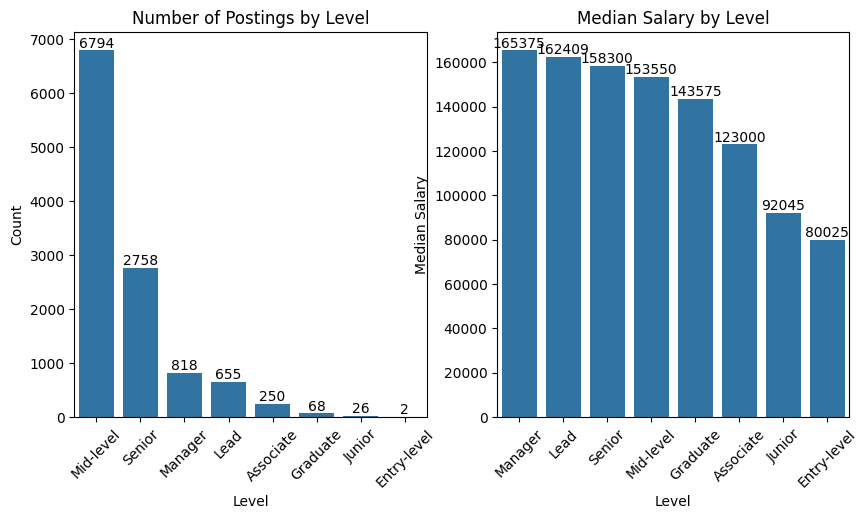

In [170]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

# plot the job by level distribution
level_dist = df_sal.groupby('Level').size().sort_values(ascending = False)
sns.barplot(x=level_dist.index, y=level_dist.values, ax=ax[0])
ax[0].bar_label(ax[0].containers[0])
ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=45)
ax[0].set_ylabel('Count')
ax[0].set_title('Number of Postings by Level')

# plot the median salary by level
level_sal = df_sal.groupby('Level')['Annual Salary'].median().sort_values(ascending = False).astype(int)
sns.barplot(x=level_sal.index, y = level_sal.values, ax = ax[1])
ax[1].bar_label(ax[1].containers[0])
ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation=45)
ax[1].set_ylabel('Median Salary')
ax[1].set_title('Median Salary by Level')
plt.show()

- Manager-level positions offer the highest median salary at around $165K, more than double the entry-level median of $80K, highlighting a strong financial incentive for career progression. 
- Graduate roles unexpectedly pay more than entry, junior, and associate positions, **suggesting inconsistencies in how companies define early-career titles** or reflecting **specialized graduate programs with higher compensation**. Salary progression at early levels is inconsistent, with junior and associate roles not increasing smoothly. 
- Mid-level roles show a median of $153K, closely matching the overall market median of $156K, indicating that mid-level hiring shapes the typical salary landscape. 
- Lead and manager roles exhibit wider salary variation, driven by differences in responsibility, seniority, and company size.

`Salary` by `Location`


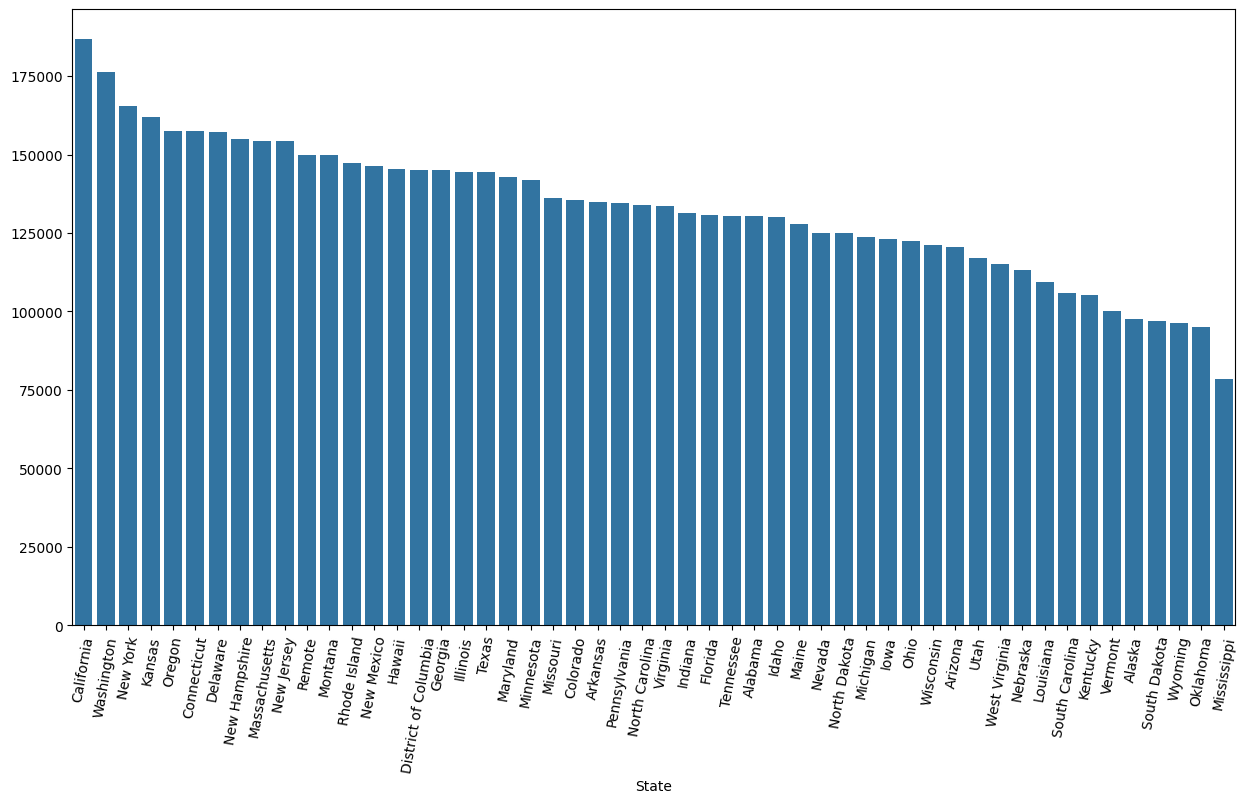

In [171]:
# plot the salary by state

state = df_sal.groupby('State')['Annual Salary'].median().sort_values(ascending=False).astype(int)
plt.figure(figsize=(15,8))
sns.barplot(x= state.index, y = state.values)
plt.xticks(rotation = 80)
plt.show()

- With a median salary of approximately $188K and the highest number of job postings, California demonstrates that major tech companies tend to offer higher compensation than other firms.

`Skills` and `Job Title`

In [172]:
skills = [
    'Data Science', 'Machine Learning', 'Deep Learning', 'AI', 'Artificial Intelligence',
    'Data Analysis', 'Data Visualization', 'Tableau', 'Power BI', 'SQL', 'NoSQL',
    'Big Data', 'Hadoop', 'Spark', 'ETL', 'Python', 'R', 'Java', 'C++', 'JavaScript',
    'HTML', 'CSS', 'AWS', 'Azure', 'GCP', 'Docker', 'Kubernetes', 'CI/CD', 
    'Project Management', 'Agile', 'Scrum', 'Communication', 'Problem Solving', 'Critical Thinking'
]

# Create a new column that will store extracted skills
def extract_skills(description):
    description = str(description).lower()  # convert to lowercase for case-insensitive match
    found_skills = [skill for skill in skills if skill.lower() in description]
    return ','.join(found_skills)  # join as comma-separated string

df_sal['Skill keywords'] = df_sal['Description'].apply(extract_skills)

df_sal[['Description', 'Skill keywords']].head()

/var/folders/5v/wc8gxzt56gx00tb3h88t55vm0000gn/T/ipykernel_25265/3985671342.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sal['Skill keywords'] = df_sal['Description'].apply(extract_skills)


,Description,Skill keywords
1,Must have strong technical skills in areas suc...,"Data Visualization,SQL,Python,R"
3,"As a data scientist, you’re excited at the pro...",R
15,Your deep data science and complimentary techn...,"Data Science,R"
29,You will also be responsible for working with ...,"Machine Learning,R"
30,Facilitate rapid experimentation and data-driv...,R


In [173]:
# Function to ensure each row becomes a list of skills
def to_skill_list(x):
    if isinstance(x, list):
        return x
    elif isinstance(x, str):
        # Split by comma and strip whitespace
        return [skill.strip() for skill in x.split(',')]
    else:
        return []

# Apply to the column
df_sal['Skill keywords'] = df_sal['Skill keywords'].apply(to_skill_list)

# Flatten the list of lists
all_skills = [skill for skills_list in df_sal['Skill keywords'] for skill in skills_list]

# Count occurrences
skill_counts = Counter(all_skills)

# Convert to DataFrame
skill_counts_df = pd.DataFrame(skill_counts.items(), columns=['Skill', 'Number_of_Postings'])
skill_counts_df = skill_counts_df.sort_values(by='Number_of_Postings', ascending=False)

print(skill_counts_df)


                      Skill  Number_of_Postings
3                         R               11371
5          Machine Learning                2885
6                        AI                2428
4              Data Science                 865
8             Deep Learning                 669
0        Data Visualization                 304
17  Artificial Intelligence                 275
11            Data Analysis                 274
2                    Python                 217
15                      AWS                 177
1                       SQL                 161
13                 Big Data                 147
7        Project Management                 103
20                      ETL                  83
9             Communication                  77
10                  Tableau                  59
19                      C++                  40
18                     Java                  37
22                    Azure                  32
14                    Spark             

/var/folders/5v/wc8gxzt56gx00tb3h88t55vm0000gn/T/ipykernel_25265/1991645719.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sal['Skill keywords'] = df_sal['Skill keywords'].apply(to_skill_list)


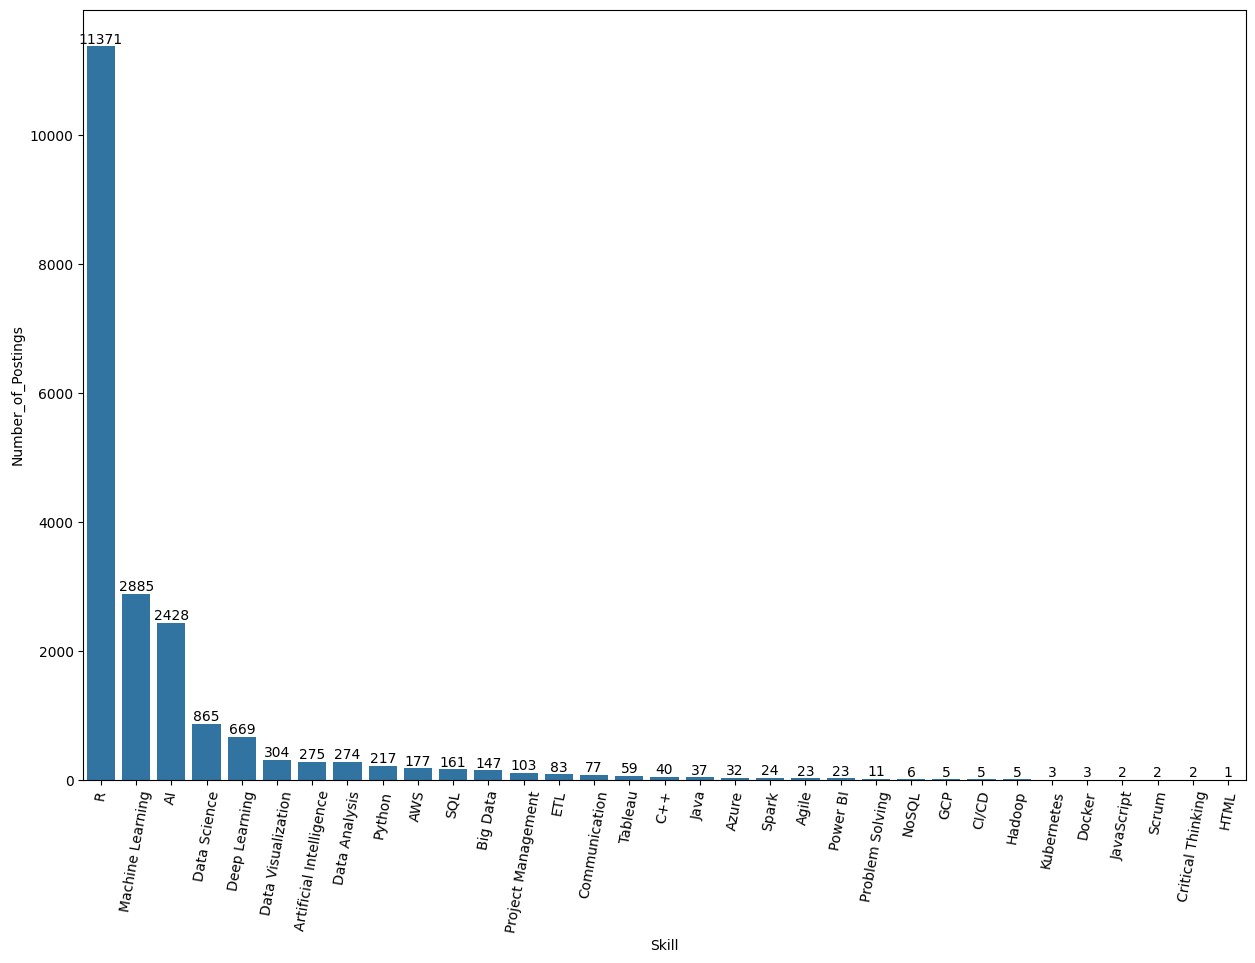

In [174]:
plt.figure(figsize=(15,10))

ax = sns.barplot(x=skill_counts_df['Skill'], y=skill_counts_df['Number_of_Postings'])
ax.bar_label(ax.containers[0])
plt.xticks(rotation=80)
plt.show()

- A total of 33 unique data-science skills are mentioned across job postings. The skill set is heavily dominated by R (11,371 postings), followed by Machine Learning (2,885), AI (2,428), and Data Science (865), highlighting a strong emphasis on analytics and artificial intelligence capabilities.

- Specialized technical skills such as Deep Learning, Data Visualization, Artificial Intelligence, and Data Analysis are moderately common, while core programming and cloud skills like Python, SQL, AWS, Big Data, Java, C++, and Azure appear less frequently.

- Project management and soft skills—Project Management, Communication, Agile, Scrum, Critical Thinking—are present but rare, indicating that technical expertise is the main focus. Other niche skills, including ETL, Tableau, Power BI, Spark, NoSQL, JavaScript, HTML, appear at the lower end of the frequency spectrum.

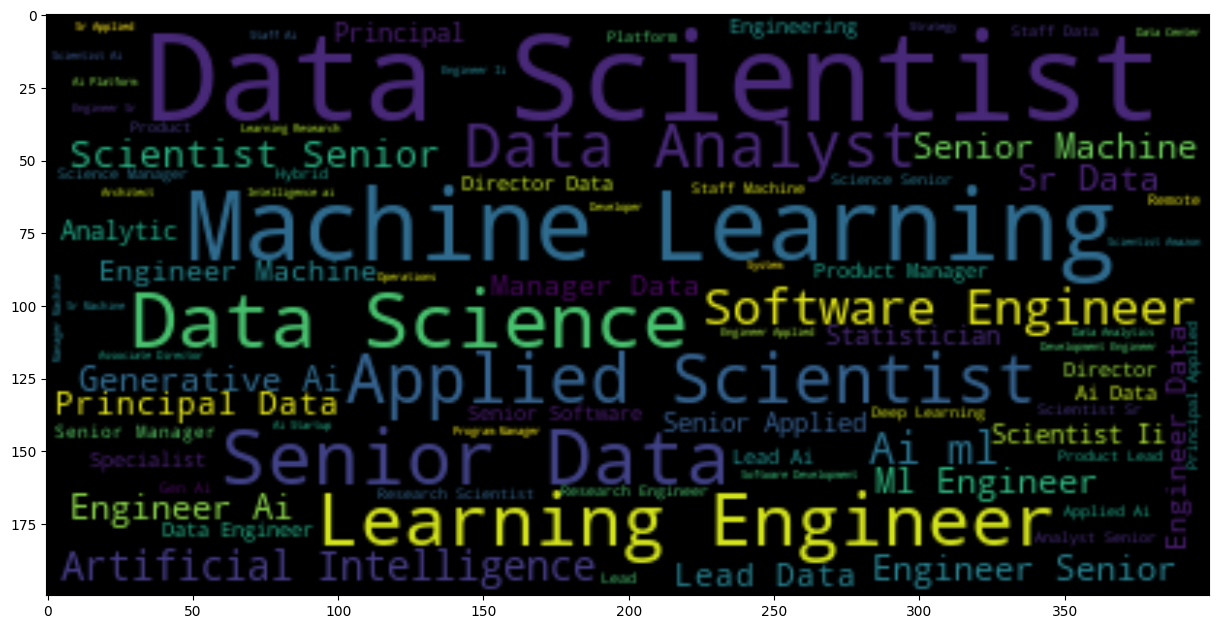

In [175]:
# visualize the most hired titles

plt.figure(figsize=(15,8))
titles = df_sal['Title'].tolist()
titles_join = ["".join(title_list) for title_list in df_sal['Title']]
all_titles = " ".join(titles_join)
wc = WordCloud().generate(all_titles)
plt.imshow(wc, interpolation='bilinear')

### Compute and plot the heatmap to see correlations b.w variabels with salary

In [176]:
df_sal.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11371 entries, 1 to 29183
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Date             11371 non-null  datetime64[ns]
 1   Title            11371 non-null  object        
 2   Company          11371 non-null  object        
 3   State            11371 non-null  object        
 4   City             11371 non-null  object        
 5   Level            11371 non-null  object        
 6   Work Mode        11371 non-null  object        
 7   Average Salary   11371 non-null  float64       
 8   Pay Type         11371 non-null  object        
 9   Employment Type  11371 non-null  object        
 10  Description      11371 non-null  object        
 11  Annual Salary    11371 non-null  float64       
 12  Weekday          11371 non-null  object        
 13  salary_pw        11371 non-null  float64       
 14  Skill keywords   11371 non-null  object    

In [177]:
from sklearn.preprocessing import LabelEncoder

df_encoded = df_sal.copy()
categorical_cols = ['Title', 'Company', 'State', 'City', 'Level', 'Work Mode', 'Pay Type', 'Employment Type']

le = LabelEncoder()
for col in categorical_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])

In [178]:
numeric_df = df_encoded.select_dtypes(include=['int64', 'float64']).drop(columns=['salary_pw','Average Salary'])
numeric_df.corr(method='pearson')

,Title,Company,State,City,Level,Work Mode,Pay Type,Employment Type,Annual Salary
Title,1.000000,0.046583,-0.033608,0.037086,0.210233,0.010324,0.004694,0.010899,0.078608
Company,0.046583,1.000000,-0.086196,-0.006395,-0.071597,-0.003467,-0.063753,-0.038454,-0.058764
State,-0.033608,-0.086196,1.000000,0.037997,-0.005338,0.034875,-0.030185,-0.031050,-0.102746
City,0.037086,-0.006395,0.037997,1.000000,0.006834,-0.008109,0.029709,0.018538,0.113350
Level,0.210233,-0.071597,-0.005338,0.006834,1.000000,-0.010150,-0.022627,-0.023479,0.028185
Work Mode,0.010324,-0.003467,0.034875,-0.008109,-0.010150,1.000000,-0.002025,0.007913,-0.004305
Pay Type,0.004694,-0.063753,-0.030185,0.029709,-0.022627,-0.002025,1.000000,0.866675,0.261023
Employment Type,0.010899,-0.038454,-0.031050,0.018538,-0.023479,0.007913,0.866675,1.000000,0.209499
Annual Salary,0.078608,-0.058764,-0.102746,0.113350,0.028185,-0.004305,0.261023,0.209499,1.000000


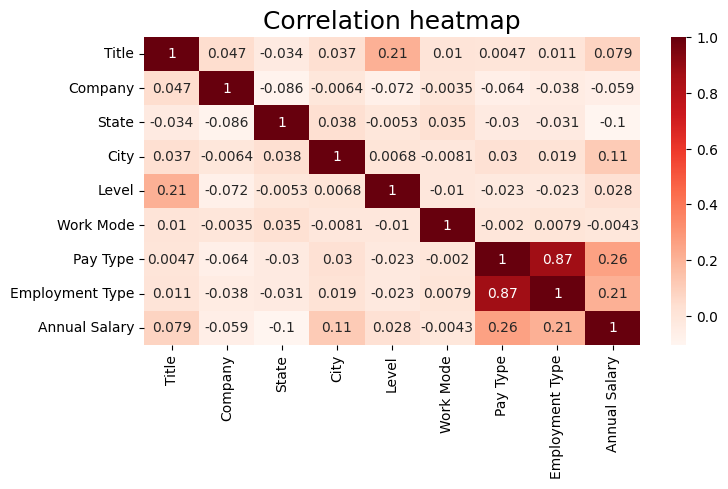

In [179]:
# Create correlation heatmap

plt.figure(figsize=(8,4))
sns.heatmap(numeric_df.corr(method='pearson'), annot=True, cmap='Reds')
plt.title('Correlation heatmap', fontsize=18)
plt.show()

### Conclusions

`Pay Type` shows the strongest positive correlation with **Annual Salary** (0.26). However, **Pay Type and Employment Type** (previously labeled as Contract) are strongly related to each other, meaning their correlations with salary may be partially driven by the same underlying job structure. This overlap (multicollinearity) could affect model performance if both variables are included without proper handling.

`Employment Type` also shows a moderate positive correlation with salary (0.21). This suggests that different forms of employment (e.g., full-time, part-time, contract, casual) offer different compensation packages, which impacts overall salary levels.

`City` and `Title` show weaker but still positive correlations with salary, indicating that certain cities pay higher or lower average salaries, and that job roles also contribute to salary differences.

`Title` and `Level` show a correlation of 0.21. This is likely influenced by the data cleaning and transformation process, where the `Level` field was derived from the job title. Because the two variables are partially dependent, a moderate correlation is expected.

